XGBoosst 핵심 특징
1. Bo

In [3]:
import xgboost
print(xgboost.__version__)

3.2.0


In [7]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [11]:
# 유방암 데이터셋을 불러오기
dataset = load_breast_cancer()
X_features = dataset.data        # 가져온 데이터셋에서 입력 변수(feature)
y_label = dataset.target         # 정답 레이블 (타겟 : 악성/양성) Label 변수에 저장

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target'] = y_label

cancer_df.head(10)       # 상위 10개

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [14]:
print(dataset.target_names)                   # 데이터셋이 어떤 레이블을 사용하는지 출력해서 확인 (
print(cancer_df['target'].value_counts())     # 0과 1이 각각 몇 개 있는지 출력해서 데이터 분포를 확인

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [15]:
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [17]:
X_features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [18]:
y_label

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [19]:
# 전체 데이터에서 학습 80%, 테스트 20% 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)

# 전체 데이터에서 90%, 테스트 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [21]:
# xgboost가 계산을 최적화하기 위해 사용되는 DMatrix 구조로 학습 데이터를 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [22]:
# 모델 학습에 필요한 하이퍼파라미터 설정
params = {
    'max_depth' : 3,  # 트리의 깊이를 3개로 제한하여 과적합 방지
    'eta' : 0.5,      # learning rate를 설정하여 한번의 학습 단계에서 조정되는 크기 설정
    'objective' : 'binary:logistic',   # 이진 분류 문제이므로 로지스틱 함수 사용해서 확률 예측
    'eval_metric' : 'logloss'          # 평가 지표로서, 로그손실을 사용
}

num_rounds = 400               #최대 boosting 반복 횟수

In [26]:
eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round= num_rounds,
    early_stopping_rounds= 50,         # 학습시, 평가할 데이터를 지정해서 학습과정에서 early stopping에 활용하여 조기 종료 수행
    evals = eval_list
)

[0]	train-logloss:0.33637	eval-logloss:0.44579
[1]	train-logloss:0.20512	eval-logloss:0.35638
[2]	train-logloss:0.13638	eval-logloss:0.30729
[3]	train-logloss:0.09867	eval-logloss:0.27589
[4]	train-logloss:0.07345	eval-logloss:0.27413
[5]	train-logloss:0.05879	eval-logloss:0.27065
[6]	train-logloss:0.04771	eval-logloss:0.26873
[7]	train-logloss:0.03821	eval-logloss:0.26627
[8]	train-logloss:0.03192	eval-logloss:0.27051
[9]	train-logloss:0.02761	eval-logloss:0.27630
[10]	train-logloss:0.02324	eval-logloss:0.27361
[11]	train-logloss:0.02011	eval-logloss:0.26487
[12]	train-logloss:0.01791	eval-logloss:0.27232
[13]	train-logloss:0.01598	eval-logloss:0.26959
[14]	train-logloss:0.01456	eval-logloss:0.25917
[15]	train-logloss:0.01352	eval-logloss:0.26260
[16]	train-logloss:0.01250	eval-logloss:0.25960
[17]	train-logloss:0.01143	eval-logloss:0.26172
[18]	train-logloss:0.01086	eval-logloss:0.26168
[19]	train-logloss:0.01029	eval-logloss:0.26545
[20]	train-logloss:0.00978	eval-logloss:0.26266
[2

In [29]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값 출력
pred_probs = xgb_model.predict(dtest)

# 예측한 확률값 중에서 처음 10개만 출력하여 예측 결과의 값을 확인
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시')
print(np.round(pred_probs[:10], 3))

#예측된 확률값이 0.5보다 크면 양성(1) 그렇지 않다면 악성(0)으로 진단
preds = [1 if x > 0.5 else 0 for x in pred_probs]

print("예측값 10개만 표시 : ", preds[:10]) 

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시
[0.977 0.005 0.746 0.004 0.995 1.    1.    1.    1.    0.   ]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [34]:
# 행렬과 정확도 계산을 위한 지표를 가져옴
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred= None, pred_probs=None):
    confusion = confusion_matrix(y_test, pred)  # 모델의 예측 결과가 실제 정답과 얼마나 일치하는지 행렬로 계산
    accuracy = accuracy_score(y_test, pred)     # 전체 예측 중에 얼마나 맞췄는지 정확도를 계산한다
    precision = precision_score(y_test, pred)   # 양성이라고 예측한 것 중에서 실제로 양성이 얼마나 되는지 정밀도를 계산
    recall = recall_score(y_test, pred)         # recall(재현율) 실제 양성 중에서 얼마나 맞게 맞추었는지 나타내는 재현율을 계산
    f1 = f1_score(y_test, pred)                 # 정밀도와 재현율의 조화 평균으로 f1 score를 계산
    roc_auc = roc_auc_score(y_test, pred)       # roc 곡선 아래 면적을 의미, auc 값은 예측의 신뢰성을 평가

    print('오차행렬')
    print(confusion)

    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, \
    F1 : {3:.4f}, AUC : {4:.4f}'.format(
        accuracy, precision, recall, f1, roc_auc
    ))

get_clf_eval(y_test, preds, pred_probs)  # 위 성능 평가 함수를 호출하여 모델의 전체 성능을 확인

오차행렬
[[34  3]
 [ 2 75]]
정확도 : 0.9561, 정밀도 : 0.9615, 재현율 : 0.9740,     F1 : 0.9677, AUC : 0.9465


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

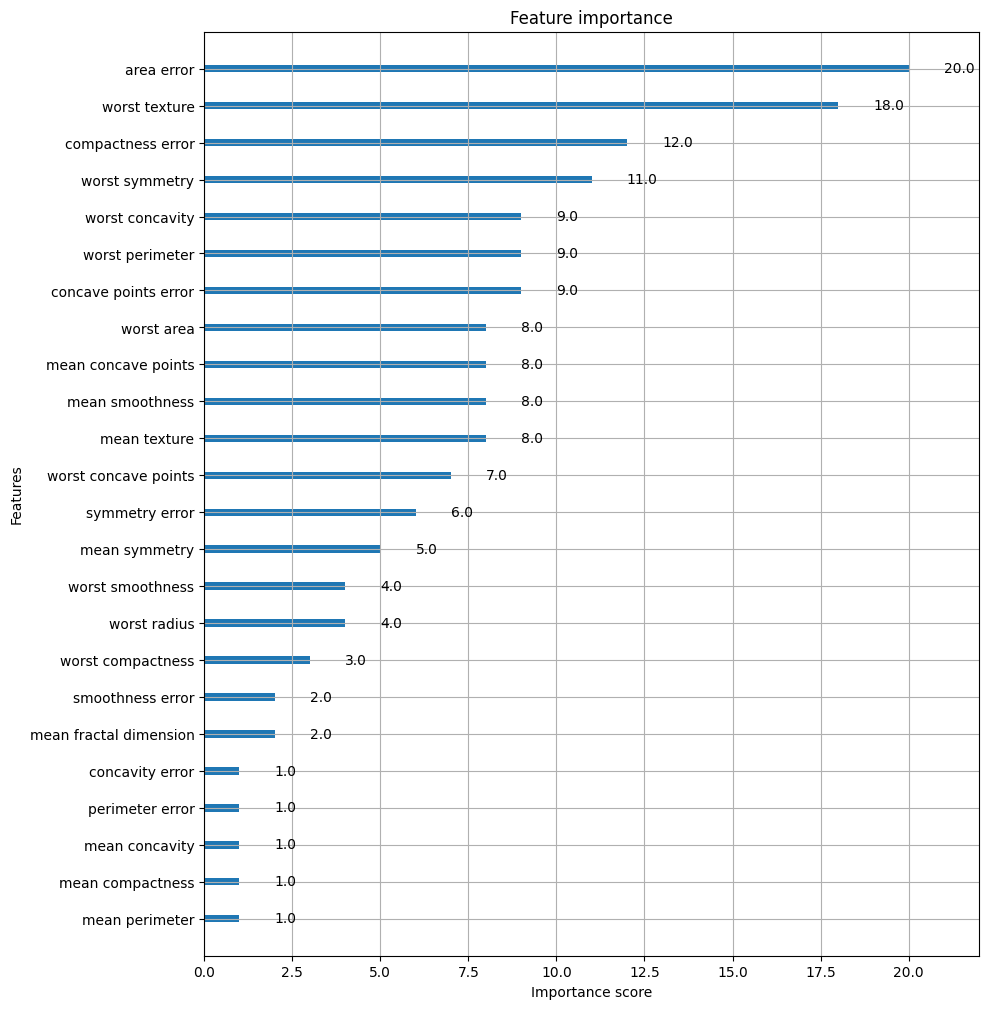

In [37]:
%matplotlib inline

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,12))

# XGBoost 모델이 학습 중 어떤 feature를 많이 사용하였는지 시각적으로 표현
# --> XGBoost가 학습하면서 양성/악성에 어떤 feature가 분류에 가장 기여했는지를 보여줌
plot_importance(xgb_model, ax=ax)